# Aproximaciones numéricas para la equivalencia de tasas

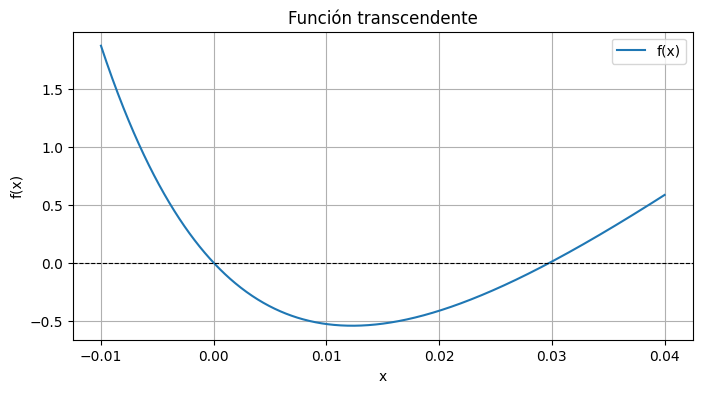

Raíz encontrada: x = 0.02979678


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Definir la función
def f(x, n, i):
    return -1 + n*(x - i) + (1 + n*i)/((1 + x)**(n))

# Definir los parámetros
n = 72
i = 0.02

# --- Gráfica ---
x = np.linspace(-0.01, 0.04, 1000)
plt.figure(figsize=(8, 4))
plt.plot(x, f(x, n, i), label='f(x)')
plt.axhline(0, color='k', linewidth=0.8, linestyle='--')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Función transcendente')
plt.grid(True)
plt.legend()
plt.show()

# --- Solución numérica ---
raiz = brentq(f, 0.0001, 1, args=(n, i))
print(f"Raíz encontrada: x = {raiz:.8f}")

In [22]:
# --- Costo total del préstamo bajo ambos esquemas ---
k = 100_000   # monto del préstamo        # número de meses
i_g = i   # tasa mensual saldos globales
i_s = raiz   # tasa mensual saldos insolutos (de la celda anterior)

# Saldos globales
cuota_global   = k / n + k * i_g
costo_global   = cuota_global * n          # = k * (1 + n * i_g)

# Saldos insolutos
cuota_insoluto = k * i_s / (1 - (1 + i_s)**(-n))
costo_insoluto = cuota_insoluto * n

print(f"Tasa saldos globales:   i_g = {i_g:.8f}")
print(f"Tasa saldos insolutos:  i_s = {i_s:.8f}")
print()
print(f"Tasa saldos globales anual:   i_g * 12 = {i_g * 12:.8f}")
print(f"Tasa saldos insolutos anual:  i_s * 12 = {i_s * 12:.8f}")
print()
print(f"Cuota mensual (global):   ${cuota_global:,.2f}")
print(f"Cuota mensual (insoluto): ${cuota_insoluto:,.2f}")
print()
print(f"Costo total (global):   ${costo_global:,.2f}")
print(f"Costo total (insoluto): ${costo_insoluto:,.2f}")
print(f"\nDiferencia: ${abs(costo_global - costo_insoluto):.6f}")

Tasa saldos globales:   i_g = 0.02000000
Tasa saldos insolutos:  i_s = 0.02979678

Tasa saldos globales anual:   i_g * 12 = 0.24000000
Tasa saldos insolutos anual:  i_s * 12 = 0.35756136

Cuota mensual (global):   $3,388.89
Cuota mensual (insoluto): $3,388.89

Costo total (global):   $244,000.00
Costo total (insoluto): $244,000.00

Diferencia: $0.000000
